# Seawater vs. T experiment

## Methods


In [1]:
import pandas as pd
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt

import pickle as pk
import re
import glob 

import pkl_dac_gather as op

from sklearn.linear_model import LinearRegression as LR

from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from matplotlib.collections import LineCollection

In [2]:
MAIN_DIR = '../74B9/'

DIN = MAIN_DIR + '20250623_S/'
FNS = np.sort(glob.glob(DIN + 'opus*pkl'))

FN_CAL = DIN + 'DAT/CALIBRAT.DAT'

In [3]:
# read wavelengths
wvr = pd.read_csv(MAIN_DIR + 'wv_74B9.csv').iloc[0, 1]
wv_cleaned = re.sub(r'[\[\]\n]', ' ', wvr)
wv = np.fromstring(wv_cleaned, sep=' ')

In [4]:
ds = op.mk_xr_dataset(FNS, wv)
ds, Ts_opus = op.add_all_temps(FN_CAL, ds) # add all temperatures
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 1108, wv: 248)
Coordinates:
  * time         (time) datetime64[ns] 9kB 2025-06-23T10:26:50.590736896 ... ...
  * wv           (wv) float64 2kB 191.0 191.8 192.5 193.3 ... 385.4 386.2 387.0
Data variables:
    Intensity    (time, wv) float64 2MB 1.068 -0.9465 -2.952 ... 4.01 5.464
    lampR0       (time) float64 9kB 1.706e+04 1.677e+04 ... 1.668e+04 1.668e+04
    lampR1       (time) float64 9kB 3.913e+03 3.849e+03 ... 3.847e+03 3.848e+03
    T            (time) float64 9kB 29.31 29.44 29.5 29.5 ... 15.62 15.59 15.62
    Fcount       (time) float64 9kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    T_RefDiode   (time) float64 9kB 29.62 29.75 29.75 ... 15.44 15.44 15.44
    T_RefSpectr  (time) float64 9kB 29.31 29.43 29.5 29.5 ... 15.59 15.59 15.59
    T_CPU        (time) float64 9kB 31.1 31.3 31.3 31.4 ... 17.8 17.8 17.8 17.8

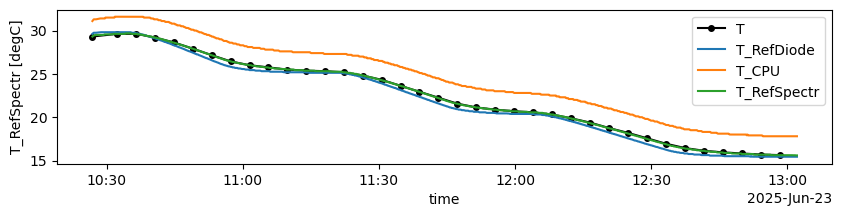

In [5]:
fig, ax = plt.subplots(1, figsize=[10,2], sharex=True)
ds['T'][::30].plot(marker='o', ms=4, c='k', ax=ax, label='T')
ds['T_RefDiode'].plot(ax=ax, label='T_RefDiode')
ds['T_CPU'].plot(ax=ax, label='T_CPU')
ds['T_RefSpectr'].plot(ax=ax, label='T_RefSpectr')

ax.legend()

In [6]:
io = 0
ilast = 2000

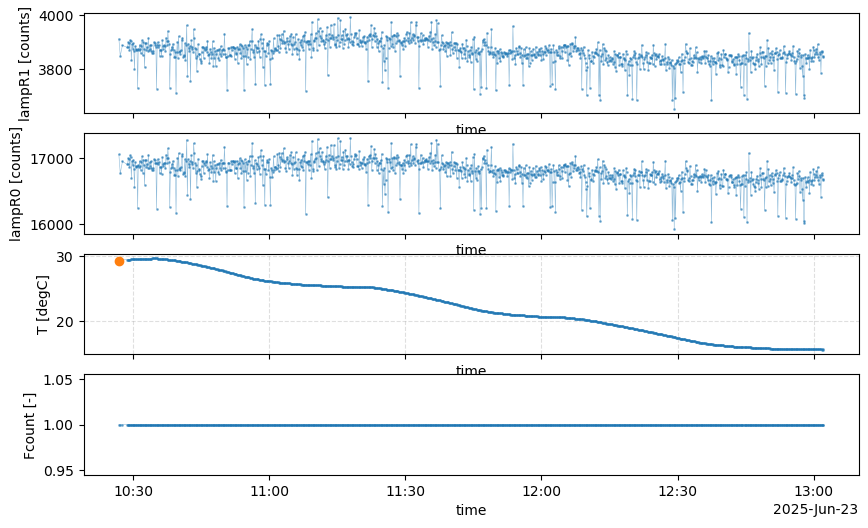

In [7]:
fig, ax = plt.subplots(4,1, figsize=[10,6], sharex=True)

ds['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0], label=None)
ds['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1])
ds['T'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[2])
ds['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3])

ax[2].grid(ls='--', alpha=0.4)

ax[2].plot(ds['time'][io], ds['T'][io], 'o')
# ax[3].set_xlim([pd.to_datetime('2025-06-12 16:40'), pd.to_datetime('2025-06-12 16:45')])

In [8]:
# i2use = np.where(ds['time'] >= pd.to_datetime('2025-06-12 16:41'))
# i2use = np.where(  (ds['time'] >= pd.to_datetime('2025-06-12 16:41')) &  (ds['time'] <= pd.to_datetime('2025-06-12 18:41'))  )
# i2use = np.arange(0, lR1.size, 1)
# i2use = np.arange(1250, 2000, 1)
# i2use = np.where(Fcount == 1)[0]
io    = np.where(ds['time'].values >= pd.to_datetime('2025-06-19 15:00'))[0]
ilast = np.where(ds['time'].values <= pd.to_datetime('2025-06-19 16:00'))[0]

ds2 = ds.sel(   time=slice('2025-06-23 10:30',   '2025-06-23 13:45' )  ) # this is to ensure that the temperature distribution is uniform

# ds2 = ds.sel(time=slice(pd.to_datetime('2025-06-12 16:41'), pd.to_datetime('2025-06-12 23:59')))
# ds2 = ds.sel(time=slice(pd.to_datetime('2025-06-12 16:41'), pd.to_datetime('2025-06-12 22:41')))

io

array([   0,    1,    2, ..., 1105, 1106, 1107], shape=(1108,))

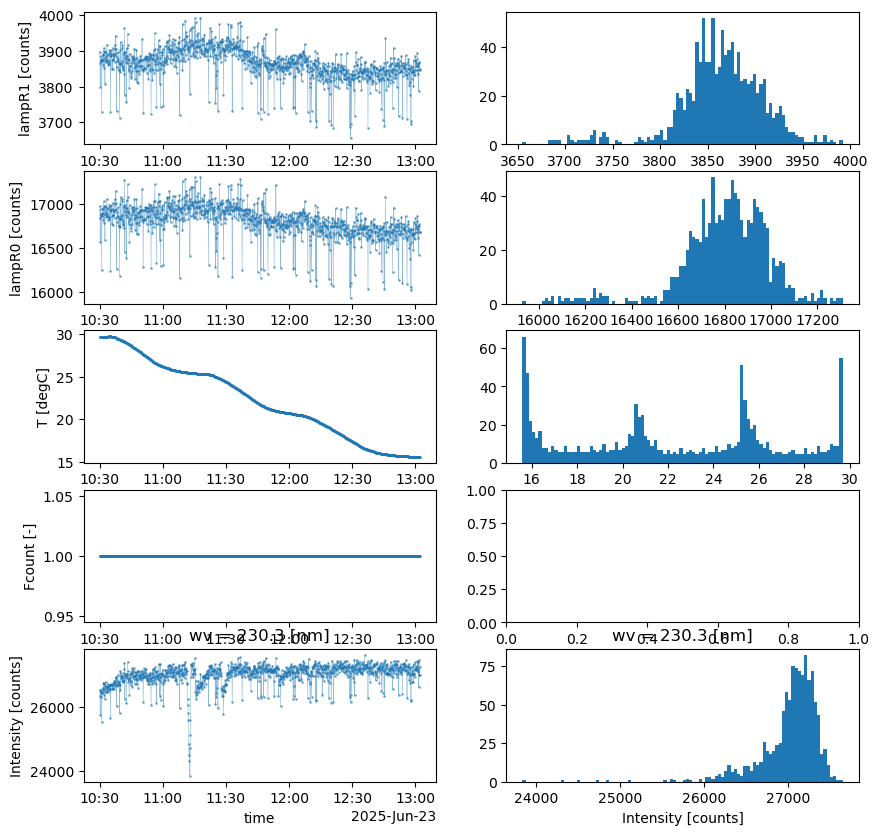

In [9]:
iwv = 50


fig, ax = plt.subplots(5,2, figsize=[10,10], sharex=False)

ds2['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0,0], label=None)
ax[0,0].set_xlabel('')
ds2['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1,0])
ax[1,0].set_xlabel('')
ds2['T'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[2,0])
ax[2,0].set_xlabel('')
ds2['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3,0])
ax[3,0].set_xlabel('')

ds2['Intensity'][:,iwv].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[4,0])



ds2['lampR1'].plot.hist(bins=100, ax=ax[0,1]); 
ds2['lampR0'].plot.hist(bins=100, ax=ax[1,1]);
ds2['T'].plot.hist(bins=100, ax=ax[2,1]);
ds2['Intensity'][:,iwv].plot.hist(bins=100, ax=ax[4,1]);


/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2512/542246600.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_lRef[ii] = lr.coef_
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2512/542246600.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_lRef[ii] = lr.coef_
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2512/542246600.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_lRef[ii] = lr.coef_
/var/folders/98/ls269b

0
1
2
3
4
break: ii =  4


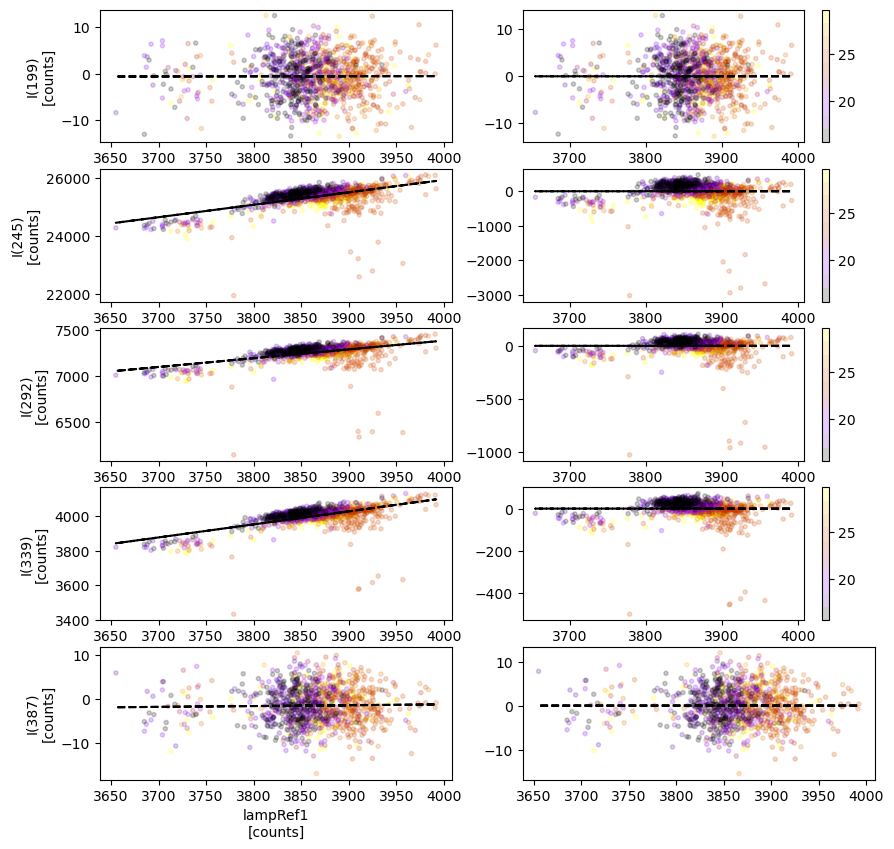

In [18]:
m_lRef = np.empty(wv.size) * np.nan
m_T = np.empty(wv.size) * np.nan
q = np.empty(wv.size) * np.nan

n_plots = 5
fig, ax = plt.subplots(n_plots, 2, figsize=[10,2*n_plots])



for ii,ip in enumerate(np.linspace(11, wv.size, n_plots).astype(int)-1):
    h = ax[ii,0].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T, c=ds2['T'], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,0].set_ylabel(f'I({wv[ip]:.0f})\n[counts]')
    ax[ii,0].set_xlabel(f'lampRef1\n[counts]')

    # m[ii], q[ii] = np.polyfit(ds2['lampR1'], ds2['Intensity'][:,ip], 1)
    X = [   ds2['lampR1'].values,
        ]
    X = np.asarray(X)
    y = ds2['Intensity'].values[:,ip]
    
    lr = LR(fit_intercept=True)
    lr.fit(X.T, y);
    
    # m_lRef[ii], m_T[ii] = lr.coef_       
    m_lRef[ii] = lr.coef_       
    
    pred = m_lRef[ii] * ds2['lampR1'].values + lr.intercept_# + m_T[ii] * ds2['T']


    
    ax[ii,0].plot(ds2['lampR1'], pred, 'k--')
    
    h = ax[ii,1].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T - pred, c=ds2['T'],  #TrefDiode_i[iLT24], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,1].plot(ds2['lampR1'], ds2['lampR1'][:]*0, 'k--')

    print(ii)
    if ii > 3:
        print('break: ii = ', ii)
        break
    
    fig.colorbar(h)

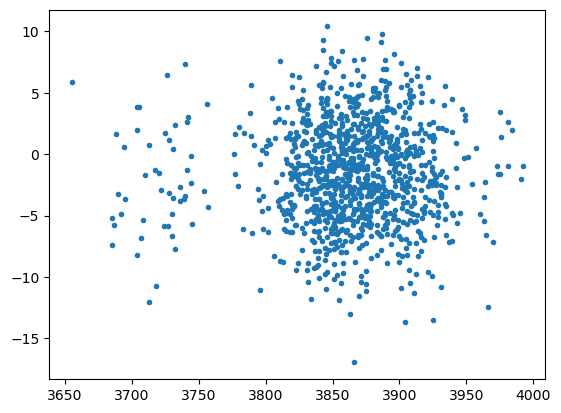

In [16]:
plt.plot(X.T, y, '.')


In [11]:
T_col = 'T'
[m_lRef1, m_T] = op.cmp_R_T_corr(ds2, T_col, DIN, fit_intercept=False)
m_lRef1_rob, m_T_rob, q = op.cmp_R_T_corr_robust(ds2, T_col, DIN)

Text(0, 0.5, 'm_T')

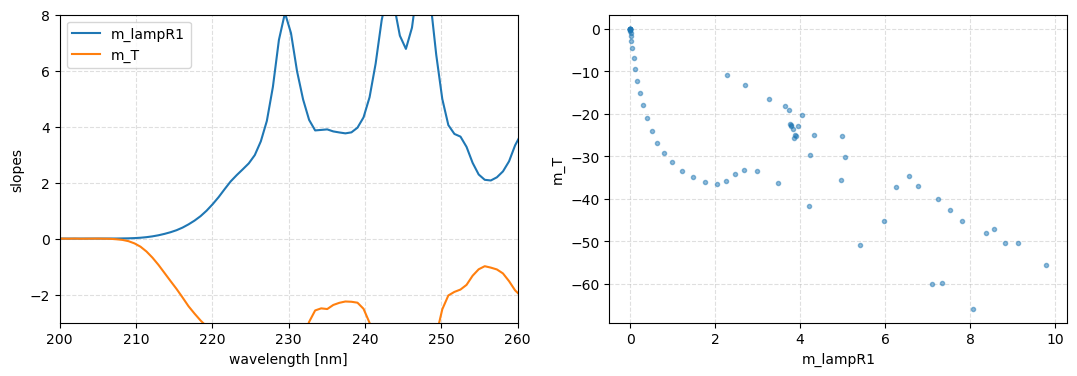

In [12]:
i200_255 = np.where( (ds2['wv'] >= 200) & (ds2['wv'] <= 255) )

fig, ax = plt.subplots(1,2, figsize=[13, 4])
ax[0].plot(ds2['wv'][:], m_lRef1[:], label='m_lampR1')
ax[0].plot(ds2['wv'][:], m_T[:]/10, label='m_T')
ax[0].legend()
ax[0].grid(ls='--', alpha=0.4)
ax[0].set_xlabel('wavelength [nm]')
ax[0].set_ylabel('slopes')
ax[0].set_ylim([-3, 8])
ax[0].set_xlim([200, 260])

ax[1].plot(m_lRef1[i200_255], m_T[i200_255], '.', alpha=0.5)
ax[1].grid(ls='--', alpha=0.4)
ax[1].set_xlabel('m_lampR1')
ax[1].set_ylabel('m_T')


Text(0, 0.5, 'm_T')

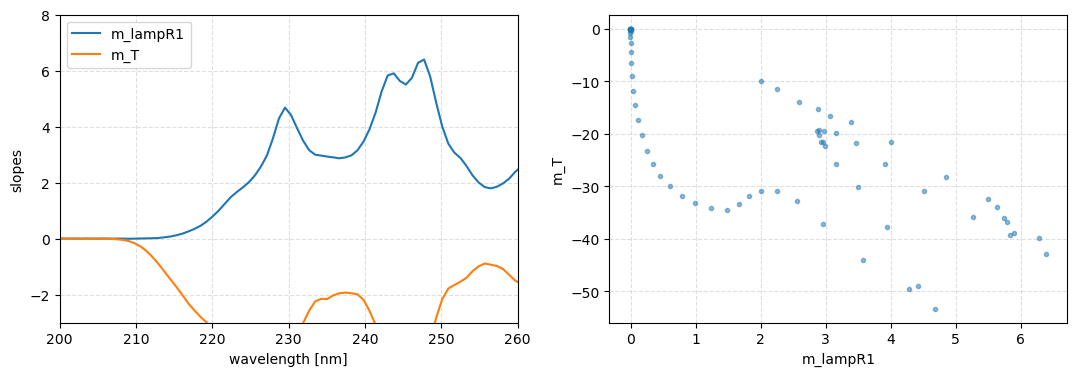

In [12]:
i200_255 = np.where( (ds2['wv'] >= 200) & (ds2['wv'] <= 255) )

fig, ax = plt.subplots(1,2, figsize=[13, 4])
ax[0].plot(ds2['wv'][:], m_lRef1[:], label='m_lampR1')
ax[0].plot(ds2['wv'][:], m_T[:]/10, label='m_T')
ax[0].legend()
ax[0].grid(ls='--', alpha=0.4)
ax[0].set_xlabel('wavelength [nm]')
ax[0].set_ylabel('slopes')
ax[0].set_ylim([-3, 8])
ax[0].set_xlim([200, 260])

ax[1].plot(m_lRef1[i200_255], m_T[i200_255], '.', alpha=0.5)
ax[1].grid(ls='--', alpha=0.4)
ax[1].set_xlabel('m_lampR1')
ax[1].set_ylabel('m_T')


In [13]:
# apply correction

io = 400

Io_Ro = ds2['Intensity'][io,:]
Io_R = np.empty(ds2['Intensity'].shape) 

dR = ds2['lampR1'].values - ds2['lampR1'][io].values
dT = ds2['T'].values - ds2['T'][io].values

Io_R_ = ds2['Intensity'][io,:].values.reshape(-1,1).T
Io_R  = ds2['Intensity'][io,:].values.reshape(-1,1).T +   m_lRef1 * dR.reshape(-1,1)   +   m_T * dT.reshape(-1,1)
Io_R_rob  = ds2['Intensity'][io,:].values.reshape(-1,1).T +   m_lRef1_rob * dR.reshape(-1,1)   +   m_T_rob * dT.reshape(-1,1)


T_  = ds2['Intensity'].values / Io_R_
A_not_corr  = -np.log10(np.asarray(T_))

T   = ds2['Intensity'].values / Io_R
A_corr = -np.log10(np.asarray(T))

T   = ds2['Intensity'].values / Io_R_rob
A_corr_rob = -np.log10(np.asarray(T))


WV  = np.ones([ds2['T'].size,1]) * wv.reshape(1,-1)

/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2232/1367550316.py:17: RuntimeWarning: divide by zero encountered in log10
  A_not_corr  = -np.log10(np.asarray(T_))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2232/1367550316.py:17: RuntimeWarning: invalid value encountered in log10
  A_not_corr  = -np.log10(np.asarray(T_))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2232/1367550316.py:20: RuntimeWarning: divide by zero encountered in log10
  A_corr = -np.log10(np.asarray(T))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2232/1367550316.py:20: RuntimeWarning: invalid value encountered in log10
  A_corr = -np.log10(np.asarray(T))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2232/1367550316.py:23: RuntimeWarning: divide by zero encountered in log10
  A_corr_rob = -np.log10(np.asarray(T))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2232/1367550316.py:23: RuntimeWarning: invalid value encountered in log10
  A

Text(164.22222222222223, 0.5, 'absorbance [-]')

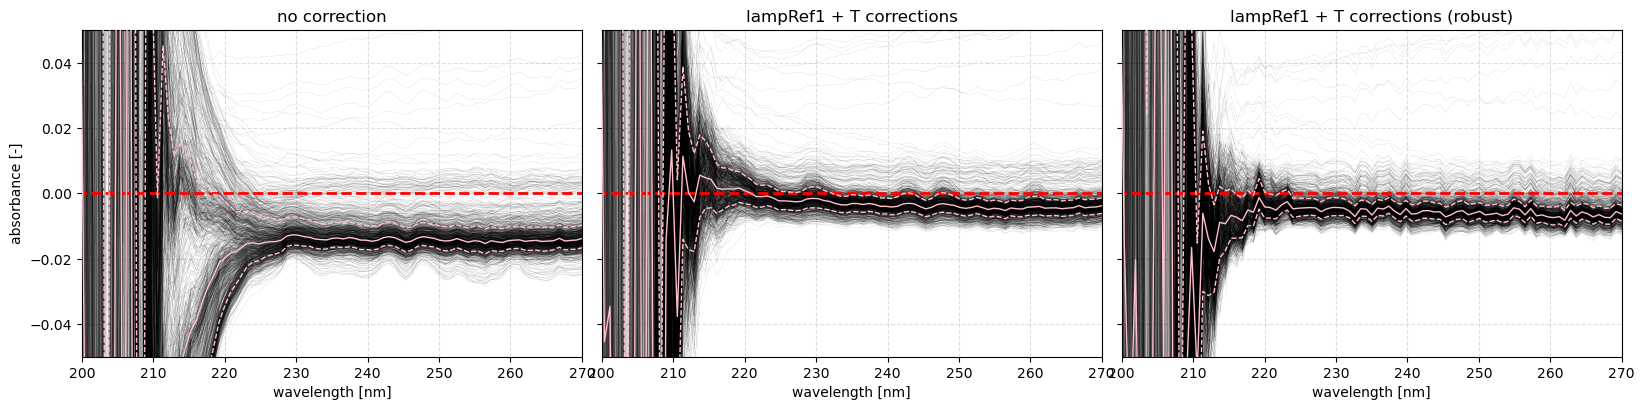

In [14]:
def make_line_collection(x, y_array, **kwargs):
    """
    Creates a LineCollection from a set of y-series sharing the same x-axis.
    x: 1D array of shape (M,)
    y_array: 2D array of shape (N, M)
    """
    # Each line segment is an array of shape (M, 2)
    segments = [np.column_stack((x, y)) for y in y_array]
    return LineCollection(segments, **kwargs)

fig, ax = plt.subplots(1, 3, figsize=[16, 4], sharex=True, sharey=True)

datasets = [
    (A_not_corr, 0),
    (A_corr, 1),
    (A_corr_rob, 2)
]

for data, i in datasets:
    # Ensure data is shaped (N, M) where M == len(wv)
    if data.shape[1] != len(wv):
        data = data.T  # transpose if needed

    lc = make_line_collection(wv, data, colors='k', linewidths=0.1, alpha=0.4)
    ax[i].add_collection(lc)
    
    ax[i].plot(wv, np.zeros_like(wv), lw=2, ls='--', c='r', alpha=1)

    median = np.nanmedian(data, axis=0)
    p16 = np.nanpercentile(data, 16, axis=0)
    p84 = np.nanpercentile(data, 84, axis=0)

    ax[i].plot(wv, median, lw=1, c='pink', zorder=60)
    ax[i].plot(wv, p84, '--', lw=1, c='pink', zorder=60)
    ax[i].plot(wv, p16, '--', lw=1, c='pink', zorder=60)

    ax[i].autoscale()  # Important when using LineCollection

    ax[i].set_xlabel('wavelength [nm]')
    ax[i].grid(ls='--', alpha=0.4)
    
plt.tight_layout()


ax[0].set_xlim([200, 270])
ax[0].set_ylim([-0.05, 0.05])
# ax[2].set_ylim([-0.025, 0.01])


ax[0].set_title('no correction')
ax[1].set_title('lampRef1 + T corrections')
ax[2].set_title('lampRef1 + T corrections (robust)')

ax[0].set_ylabel('absorbance [-]')
# ax[0].set_ylabel('absorbance [-]')

In [17]:
i200_255 = np.where((ds2['wv'] >= 200) & (ds2['wv'] <= 255))[0]

A_flat = A_not_corr[:,i200_255].flatten()
innan_ = np.where(~np.isnan(A_flat))[0]
print((np.nanpercentile(A_flat[innan_], 84) - np.nanpercentile(A_flat[innan_], 16)) / 2 / np.nanpercentile(A_flat[innan_], 50))
# print( np.nanstd(A_flat[innan_]) / np.nanmean(A_flat[innan_]))
print()

Aflat = A_corr[:,i200_255].flatten()
innan = np.where(~np.isnan(Aflat))[0]
print((np.nanpercentile(Aflat[innan], 84) - np.nanpercentile(Aflat[innan], 16)) / 2 / np.nanpercentile(Aflat[innan], 50))
# print( np.nanstd(Aflat[innan_]) / np.nanmean(Aflat[innan_]))
print()

A__flat = A_corr_rob[:,i200_255].flatten()
innan = np.where(~np.isnan(A__flat))[0]
print((np.nanpercentile(A__flat[innan], 84) - np.nanpercentile(A__flat[innan], 16)) / 2 / np.nanpercentile(A__flat[innan], 50))
# print( np.nanstd(A__flat[innan_]) / np.nanmean(A__flat[innan_]))

-1.3207708949218984

-0.8275700865998451

-0.8622084316398048


In [145]:
ds2['T'].shape

(1446,)